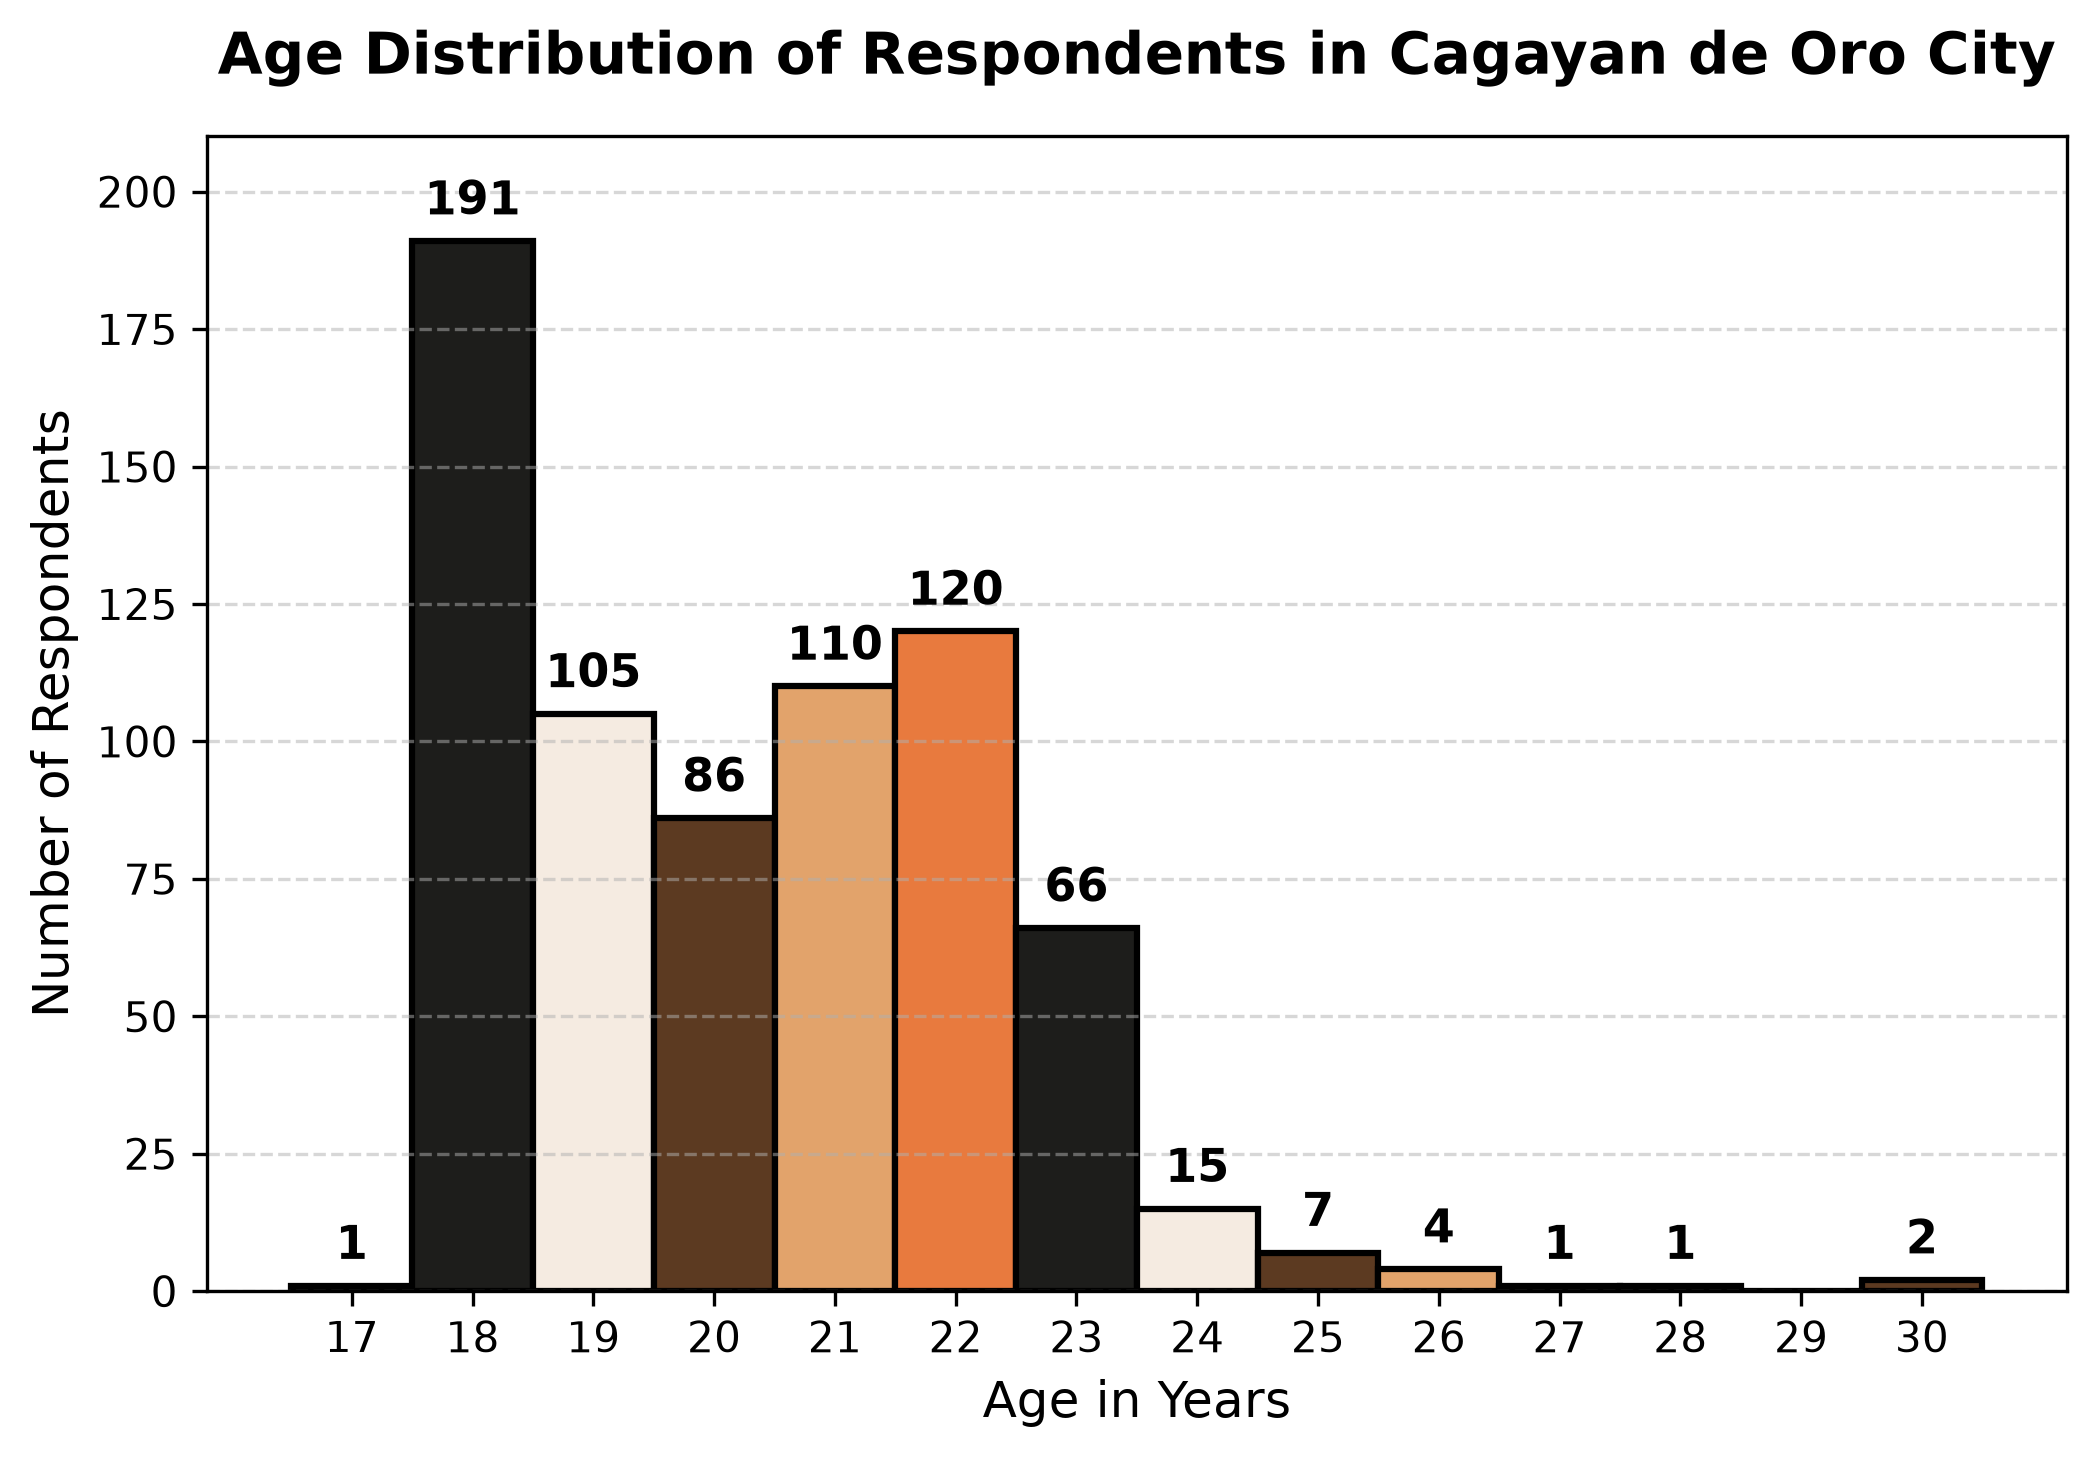

Success! The Calico chart with numbers has been saved to: data_visualization\Age_Distribution.png


In [5]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load the cleaned data
cleaned_df = pd.read_csv("rawdata/Cleaned_Data.csv")
ages = cleaned_df['Age'].dropna()

# 2. Set up the high-resolution figure
plt.figure(figsize=(8, 5), dpi=300)

calico_colors = ['#E87A3E', '#1D1D1B', '#F5EBE1', '#5C3A21', '#E2A36B']

min_age = int(ages.min())
max_age = int(ages.max())
exact_bins = np.arange(min_age, max_age + 2) - 0.5

# 3. Create the histogram
n, bins, patches = plt.hist(ages, bins=exact_bins, edgecolor='black', linewidth=1.5)

# --- NEW: Give the chart 10% more breathing room at the top so text isn't cut off ---
plt.ylim(0, max(n) * 1.1)

# 4. Loop through each bar to color it AND add the text
for i, patch in enumerate(patches):
    # Set the Calico color
    patch.set_facecolor(calico_colors[i % len(calico_colors)])

    # Get the height of the bar (which is the actual count of people)
    count = int(patch.get_height())

    # Only add text if the bar actually has people in it
    if count > 0:
        # Find the center-top point of the bar
        x_center = patch.get_x() + patch.get_width() / 2

        # --- NEW: Add the text number ---
        # (max(n) * 0.015) pushes the text slightly above the bar so it's readable
        plt.text(
            x_center,
            count + (max(n) * 0.015),
            str(count),
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold',
            color='black',
        )

plt.xticks(range(min_age, max_age + 1))
plt.title("Age Distribution of Respondents in Cagayan de Oro City", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Age in Years", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Save to the specific folder
save_folder = "data_visualization"
os.makedirs(save_folder, exist_ok=True)

file_path = os.path.join(save_folder, "Age_Distribution.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"Success! The Calico chart with numbers has been saved to: {file_path}")